# 03 · Customer Churn Model
LogReg vs Random Forest, ROC-AUC selection, permutation importance. `nationality_region` is EXCLUDED from features.
Reference command: `python src/train_churn_model.py`

In [1]:
import os, sys
sys.path.insert(0, os.path.abspath('..'))
import pandas as pd, numpy as np
from src import config
from src.utils import load_json
cm=load_json(config.METRICS_DIR/'churn_model_metrics.json')
print('Selected model:', cm['selected_model'])
print('Excluded protected attribute:', cm['excluded_protected_attribute'])
pd.DataFrame(cm['all_candidates']).T

Selected model: logistic_regression
Excluded protected attribute: nationality_region


,accuracy,precision,recall,f1,roc_auc
logistic_regression,1.0,1.0,1.0,1.0,1.0
random_forest,1.0,1.0,1.0,1.0,1.0


## Figures

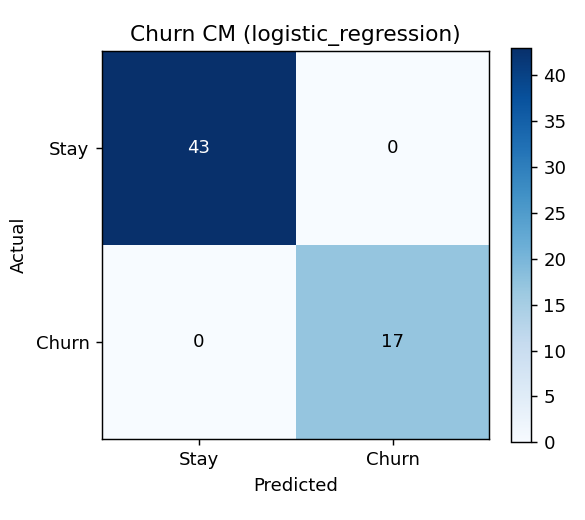

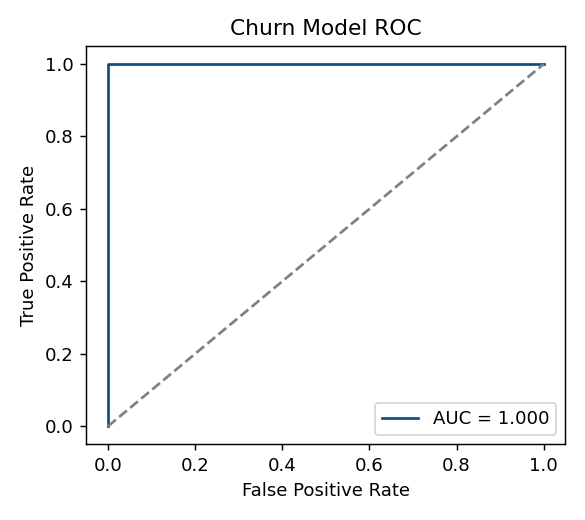

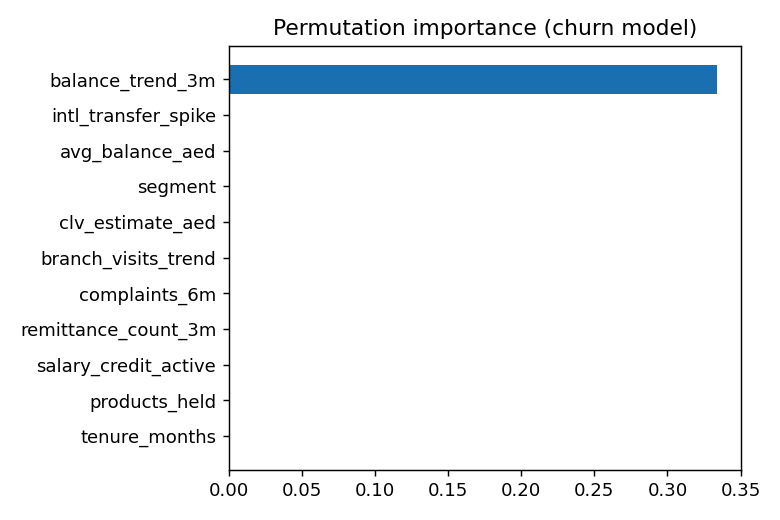

In [2]:
from IPython.display import Image, display
for f in ['churn_confusion_matrix.png','churn_roc_curve.png','churn_feature_importance.png']:
    p=config.FIGURES_DIR/f
    if p.exists(): display(Image(str(p)))

## Feature importance (permutation)

In [3]:
pd.Series(cm['permutation_importance']).sort_values(ascending=False).head(8)

balance_trend_3m        0.33388
intl_transfer_spike     0.00046
avg_balance_aed         0.00009
tenure_months           0.00000
products_held           0.00000
salary_credit_active    0.00000
remittance_count_3m     0.00000
complaints_6m           0.00000
dtype: float64

`balance_trend_3m` dominates — a sharply draining balance is the strongest churn signal, matching the relocation scenario.